# 05 — Heatmap MRR@5 per Query per Metode

**Pertanyaan yang dijawab:** Query mana yang konsisten gagal/berhasil di semua metode? Apakah ada pola antara tipe query (tabel vs narasi) dengan performa retrieval?

**Cara baca:** Warna merah = MRR tinggi (retrieval baik), kuning/putih = MRR rendah/0 (gagal). Baris berwarna merah solid di semua kolom = query yang mudah untuk semua metode.

> **Prasyarat:** Jalankan `00_load_data.ipynb` terlebih dahulu.

## 1. Import & Load Cache

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

PKL_DIR = Path("_cache")

with open(PKL_DIR / "data_eval.pkl", "rb") as f:
    cache = pickle.load(f)

top5    = cache["top5"]
qa_type = cache["qa_type"]
FIG_DIR = cache["FIG_DIR"]

METHOD_ORDER = ["Element-Based", "MaxMin Semantic", "Recursive"]

plt.rcParams.update({"font.family": "sans-serif", "font.size": 11})
print(f"Top-5 rows: {top5.shape[0]}")

Top-5 rows: 90


## 2. Pivot & Urutkan Data

In [2]:
# Pivot: baris = query_id, kolom = metode, nilai = MRR@5
heat_df = (
    top5
    .pivot_table(index="query_id", columns="method", values="mrr", aggfunc="mean")
    .reindex(columns=METHOD_ORDER)
    .fillna(0)
)

# Tambah kolom bantu untuk sorting
heat_df["type"]     = heat_df.index.map(qa_type)
heat_df["mean_mrr"] = heat_df[METHOD_ORDER].mean(axis=1)

# Urutkan: narasi dulu (abjad tipe), lalu descending MRR
heat_df = heat_df.sort_values(["type", "mean_mrr"], ascending=[True, False])

# Label sumbu Y: query ID + tipe singkat
y_labels = [
    f"{qid}  [{heat_df.loc[qid, 'type'][0].upper()}]"
    for qid in heat_df.index
]

plot_data = heat_df[METHOD_ORDER].astype(float)
n_narasi  = (heat_df["type"] == "narasi").sum()

print(f"Narasi: {n_narasi} query | Tabel: {len(heat_df) - n_narasi} query")
display(plot_data.head())

Narasi: 5 query | Tabel: 25 query


method,Element-Based,MaxMin Semantic,Recursive
query_id,,,
Q034,1.00,0.5000,1.00
Q010,1.00,0.3333,0.50
Q044,1.00,0.5000,0.25
Q029,0.25,1.0000,0.00
Q005,0.00,0.0000,0.00


## 3. Plot Heatmap

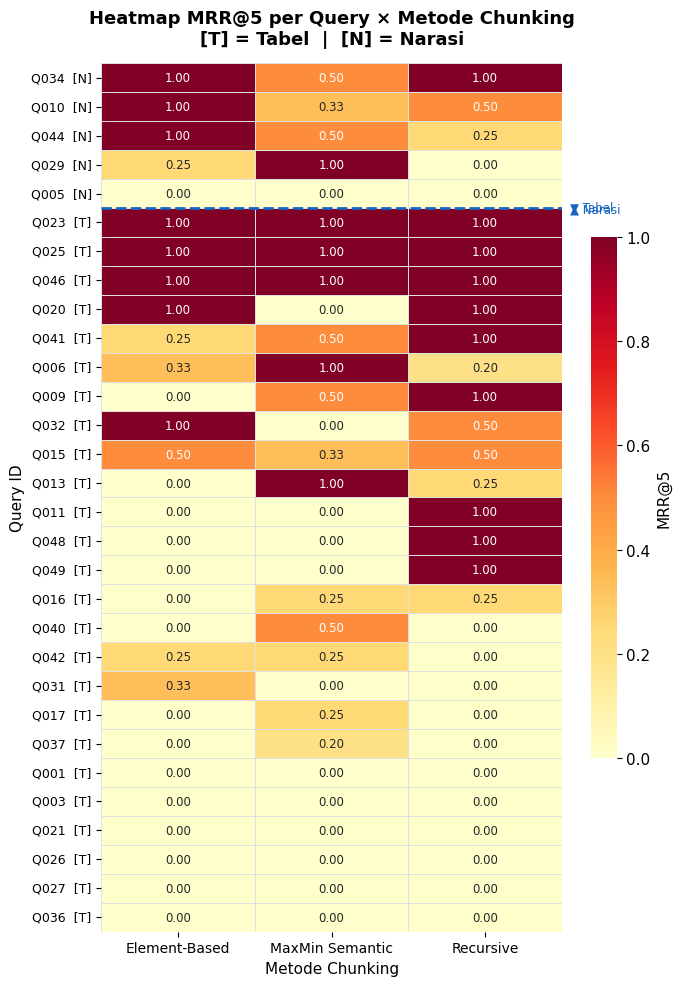

In [3]:
fig, ax = plt.subplots(figsize=(7, 10))

sns.heatmap(
    plot_data,
    ax=ax,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 8.5},
    linewidths=0.4, linecolor="#e0e0e0",
    cbar_kws={"label": "MRR@5", "shrink": 0.6},
    yticklabels=y_labels,
)

ax.set_title(
    "Heatmap MRR@5 per Query × Metode Chunking\n"
    "[T] = Tabel  |  [N] = Narasi",
    fontsize=13, fontweight="bold", pad=14,
)
ax.set_xlabel("Metode Chunking")
ax.set_ylabel("Query ID")
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=10)

# Garis pemisah narasi / tabel
ax.axhline(n_narasi, color="#1565C0", linewidth=2, linestyle="--")
ax.text(3.05, n_narasi - 0.2, "▲ Narasi",
        color="#1565C0", fontsize=8.5, va="top")
ax.text(3.05, n_narasi + 0.2, "▼ Tabel",
        color="#1565C0", fontsize=8.5, va="bottom")

fig.tight_layout()
plt.show()

## 4. Query yang Selalu Gagal (MRR = 0 di Semua Metode)

In [4]:
always_fail = plot_data[(plot_data == 0).all(axis=1)]
print(f"Query gagal di semua metode (MRR=0): {len(always_fail)} dari {len(plot_data)}")

# Tampilkan dengan tipe
fail_info = always_fail.copy()
fail_info["type"] = [qa_type.get(qid, "?") for qid in fail_info.index]

# Tambah pertanyaan
q_map = {item["id"]: item["question"] for item in __import__('json').load(
    open(Path('../data/ground_truth/qa_pairs_binary.json'), encoding='utf-8')
)}
fail_info["question"] = [q_map.get(qid, "")[:70] + "..." for qid in fail_info.index]
display(fail_info[["type", "question"]])

Query gagal di semua metode (MRR=0): 7 dari 30


method,type,question
query_id,,
Q005,narasi,Apa yang dimaksud dengan Nilai Konstruksi yang...
Q001,tabel,Berapa nilai Benchmark Indeks Hari-Orang Peker...
Q003,tabel,Berapa nilai Benchmark Indeks Upah Pekerja Tid...
Q021,tabel,Berapa proporsi Transfer Masuk untuk COPNI 8 d...
Q026,tabel,Berapa nilai Pajak Pendapatan pemerintah daera...
Q027,tabel,Berapa nilai Pembentukan Modal Tetap Bruto Pem...
Q036,tabel,Berapa estimasi Angka Partisipasi Sekolah (APS...


## 5. Simpan PNG

In [5]:
out_path = FIG_DIR / "05_mrr_heatmap.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Tersimpan: {out_path.resolve()}")

Tersimpan: D:\My Files\Kuliah\SKRIPSI\rag-skripsi\results\final\figures\05_mrr_heatmap.png


## 6. Interpretasi

- Query **narasi** (N) umumnya MRR lebih tinggi karena kontennya panjang dan lebih mudah di-match secara semantik.
- Query **tabel** (T) yang membutuhkan angka spesifik dari satu sel tabel (misal Q001, Q003) sering gagal karena chunk tabel terpotong saat preprocessing — angka tersebut tidak ada di vektor manapun.
- **Query yang selalu gagal** (MRR=0 di semua metode) perlu dianalisis lebih lanjut — bisa jadi masalah chunking pada tabel multi-baris, atau query terlalu spesifik.